# Simulation sweep results

Load stored results from the four simulation sweeps run via
`dimensionality_manuscript.scripts.run_simulations`:

- `stim_full_sweep` — `StimFullSweepConfig`
- `placefield_thresholded_sweep` — `ThresholdedGPSweepConfig`
- `placefield_smooth_sweep` — `SmoothGPSweepConfig`
- `placefield_tilbury_sweep` — `TilburySweepConfig`

Each sweep is a Cartesian product over its parameter grid; every cell stores oracle
and empirical kappa/SVD spectra from 4 independent data draws.

In [59]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline

import numpy as np
from matplotlib import pyplot as plt
from dimilibi.helpers import gaussian_filter, fit_powerlaw_derivatives
from vrAnalysis.helpers.plotting import beeswarm

from dimensionality_manuscript import ResultsAggregator, ResultsStore
from dimensionality_manuscript.configs.simulation_sweep import (
    SIMULATION_SESSION,
    SmoothGPSweepConfig,
    StimFullSweepConfig,
    ThresholdedGPSweepConfig,
    TilburySweepConfig,
)
from dimensionality_manuscript.registry import RegistryPaths

plt.rcParams["font.size"] = 14

In [2]:
store = ResultsStore(RegistryPaths().pipeline_v2_db_path)
sessions = [SIMULATION_SESSION]

SWEEP_CONFIGS = {
    "stim_full": StimFullSweepConfig,
    "placefield_thresholded": ThresholdedGPSweepConfig,
    "placefield_smooth": SmoothGPSweepConfig,
    "placefield_tilbury": TilburySweepConfig,
}

aggregators: dict[str, ResultsAggregator] = {
    name: ResultsAggregator(cfg_cls, store, sessions)
    for name, cfg_cls in SWEEP_CONFIGS.items()
}

In [3]:
for name, agg in aggregators.items():
    n_grid = len(agg.config_class.generate_variations())
    n_stored = len(agg._cells)
    print(f"{name}")
    print(f"  grid size:  {n_grid}")
    print(f"  stored:     {n_stored} ({n_stored / n_grid:.1%})")
    print(f"  param axes: {list(agg.param_axes.keys())}")
    print()

stim_full
  grid size:  1152
  stored:     1148 (99.7%)
  param axes: ['num_neurons', 'stim_dim', 'alpha_stim', 'nuisance_dim', 'nuisance_scale', 'nuisance_alignment', 'noise_scale']

placefield_thresholded
  grid size:  432
  stored:     430 (99.5%)
  param axes: ['num_neurons', 'repeat_noise_alpha', 'noise_level', 'nuisance_scale', 'lengthscale', 'threshold_pct']

placefield_smooth
  grid size:  216
  stored:     216 (100.0%)
  param axes: ['num_neurons', 'repeat_noise_alpha', 'noise_level', 'nuisance_scale', 'lengthscale']

placefield_tilbury
  grid size:  1296
  stored:     1290 (99.5%)
  param axes: ['num_neurons', 'repeat_noise_alpha', 'noise_level', 'nuisance_scale', 'sigma_mean', 'exponent_mean', 'exponent_spread']



## Result keys

Each stored cell contains oracle and empirical spectra. Kappa modes use the
`sf` (stim vs full) pairing for the standard shared-variance ratio.

In [4]:
# Peek at keys from the first stored cell (lazy — one blob fetch).
sample_agg = next(iter(aggregators.values()))
sample_agg._peek_discover_keys()
print("Result keys:")
for key in sorted(sample_agg._discovered_keys):
    print(f"  {key}")

Result keys:
  empirical_kappa_ff
  empirical_kappa_sf
  empirical_kappa_ss
  empirical_svd_ff
  empirical_svd_sf
  empirical_svd_sf_cv
  empirical_svd_ss
  empirical_svd_ss_cv
  n_neurons
  n_stimuli
  oracle_kappa_ff
  oracle_kappa_sf
  oracle_kappa_ss
  oracle_lambda_full
  oracle_lambda_stim
  oracle_lambda_stim_nuisance
  oracle_svd_ff
  oracle_svd_sf
  oracle_svd_ss


## Helpers

Scalar SVR from stored kappa mode vectors, and a convenience wrapper around
`ResultsAggregator.sel`.

In [52]:
KAPPA_KEYS = (
    "oracle_kappa_ss",
    "oracle_kappa_sf",
    "oracle_kappa_ff",
    "empirical_kappa_ss",
    "empirical_kappa_sf",
    "empirical_kappa_ff",
)
SVD_KEYS = (
    "oracle_svd_ss",
    "oracle_svd_sf",
    "oracle_svd_ff",
    "empirical_svd_ss",
    "empirical_svd_sf",
    "empirical_svd_ff",
    "empirical_svd_ss_cv",
    "empirical_svd_sf_cv",
)

def kappa_svr(candidate_modes: np.ndarray, reference_modes: np.ndarray) -> float:
    """Sum-of-modes ratio (stim vs full kappa pairing)."""
    denom = float(np.nansum(reference_modes))
    if denom <= 0.0:
        return np.nan
    return float(np.nansum(candidate_modes) / denom)


def add_svr_fields(
    arrays: dict[str, np.ndarray],
    *,
    candidate_key: str = "oracle_kappa_sf",
    reference_key: str = "oracle_kappa_ff",
    out_key: str = "svr",
) -> dict[str, np.ndarray]:
    """Add a scalar SVR field computed from paired kappa spectra."""
    candidate = arrays[candidate_key]
    reference = arrays[reference_key]
    with np.errstate(invalid="ignore", divide="ignore"):
        denom = np.nansum(reference, axis=-1)
        arrays[out_key] = np.where(denom > 0, np.nansum(candidate, axis=-1) / denom, np.nan)
    return arrays


def add_log_rms_error_fields(
    arrays: dict[str, np.ndarray],
    *,
    candidate_key: str = "empirical_kappa_ff",
    reference_key: str = "oracle_kappa_ff",
    out_key: str = "svr",
    permit_shortening: bool = False,
) -> dict[str, np.ndarray]:
    """Add a scalar SVR field computed from paired kappa spectra."""
    candidate = arrays[candidate_key]
    reference = arrays[reference_key]
    if candidate.shape[-1] != reference.shape[-1]:
        if permit_shortening:
            shorter_shape = min(candidate.shape[-1], reference.shape[-1])
            candidate = candidate[..., :shorter_shape]
            reference = reference[..., :shorter_shape]
        else:
            raise ValueError("Candidate and reference must have the same shape!!!")
    
    idx_valid = np.isfinite(candidate) & np.isfinite(reference) & (candidate > 0) & (reference > 0)
    with np.errstate(invalid="ignore", divide="ignore"):
        squared_error = (np.log(candidate) - np.log(reference)) ** 2
        arrays[out_key] = np.nanmean(squared_error * idx_valid, axis=-1)
    return arrays


def sel_kappa(agg: ResultsAggregator, **params) -> tuple[dict[str, np.ndarray], dict[str, list]]:
    """Slice the aggregator to kappa (and scalar metadata) keys."""
    return agg.sel(
        keys=list(KAPPA_KEYS) + ["n_neurons", "n_stimuli"],
        return_param_sizes=True,
        **params,
    )

def sel_svd(agg: ResultsAggregator, **params) -> tuple[dict[str, np.ndarray], dict[str, list]]:
    """Slice the aggregator to SVD (and scalar metadata) keys."""
    return agg.sel(
        keys=list(SVD_KEYS) + ["n_neurons", "n_stimuli"],
        return_param_sizes=True,
        **params,
    )

## Example: oracle vs empirical kappa SVR

Flatten all grid points from each sweep and compare true vs estimated SVR
(empirical kappa, stim-vs-full pairing).

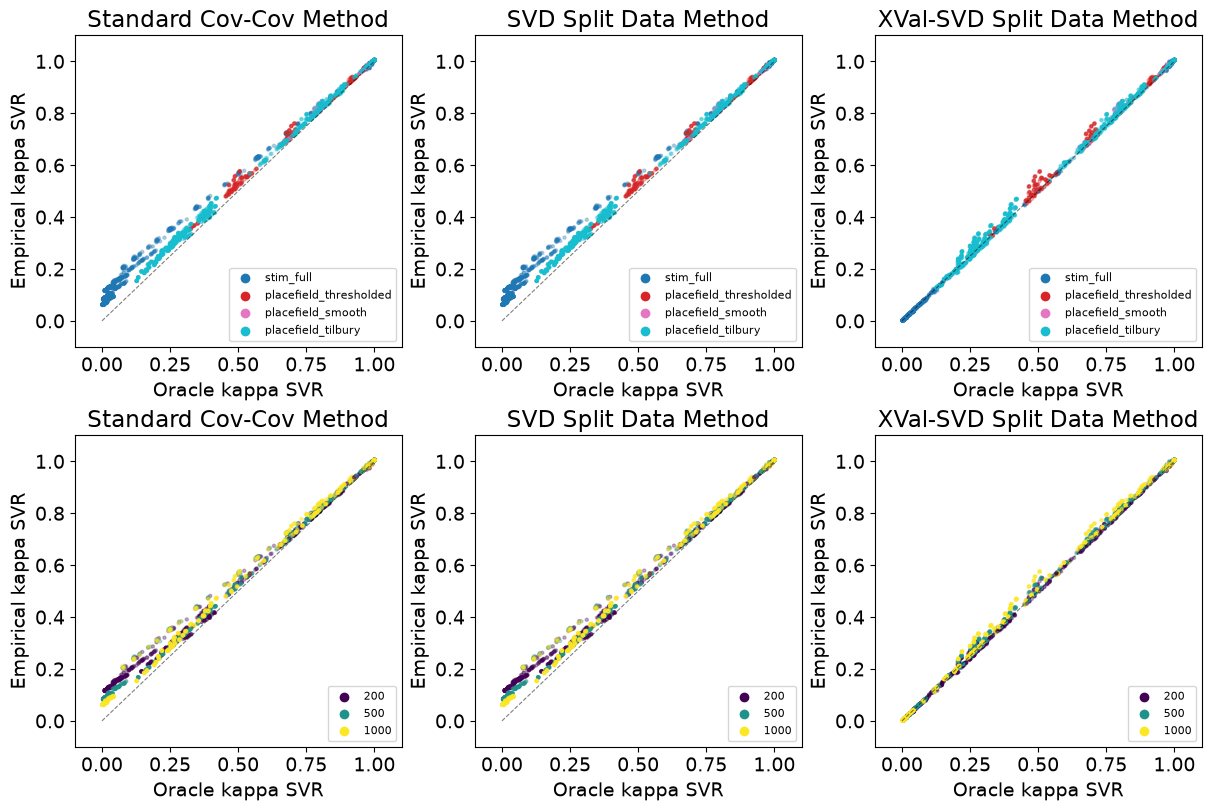

In [6]:
oracle_kappa_all = []
empirical_kappa_all = []
oracle_svd_all = []
empirical_svd_all = []
empirical_svd_cv_all = []

# Set up color maps
colors_simulations = plt.colormaps["tab10"](np.linspace(0, 1, len(aggregators)))
color_map_simulations = dict(zip(aggregators.keys(), colors_simulations))
num_neurons_all = np.unique(np.concatenate([np.array(agg.param_axes["num_neurons"]) for agg in aggregators.values()]))
colors_neurons = plt.colormaps["viridis"](np.linspace(0, 1, len(num_neurons_all)))
color_map_neurons = dict(zip(num_neurons_all, colors_neurons))

colors_simulation = []
colors_neurons = []

for icolor, (name, agg) in enumerate(aggregators.items()):
    arrays, param_sizes = sel_kappa(agg)
    add_svr_fields(arrays, candidate_key="oracle_kappa_sf", reference_key="oracle_kappa_ff", out_key="oracle_svr")
    add_svr_fields(arrays, candidate_key="empirical_kappa_sf", reference_key="empirical_kappa_ff", out_key="empirical_svr")

    oracle = arrays["oracle_svr"].ravel()
    empirical = arrays["empirical_svr"].ravel()
    valid = np.isfinite(oracle) & np.isfinite(empirical)

    oracle_kappa_all.append(oracle[valid])
    empirical_kappa_all.append(empirical[valid])
    colors_simulation.extend([name] * valid.sum())

    num_neurons_idx = list(param_sizes).index("num_neurons")
    num_neurons = np.array(agg.param_axes["num_neurons"])
    target_shape = arrays["oracle_svr"].shape
    view = [1] * len(target_shape)
    view[num_neurons_idx] = -1
    num_neurons_array = np.broadcast_to(num_neurons.reshape(view), target_shape)
    num_neurons_array = num_neurons_array.ravel()
    colors_neurons.extend((num_neurons_array[valid]))

    # Then do same for SVD
    arrays, param_sizes = sel_svd(agg)
    add_svr_fields(arrays, candidate_key="oracle_svd_sf", reference_key="oracle_svd_ff", out_key="oracle_svr")
    add_svr_fields(arrays, candidate_key="empirical_svd_sf", reference_key="empirical_svd_ff", out_key="empirical_svr")
    add_svr_fields(arrays, candidate_key="empirical_svd_sf_cv", reference_key="empirical_svd_ff", out_key="empirical_svr_cv")

    oracle = arrays["oracle_svr"].ravel()
    empirical = arrays["empirical_svr"].ravel()
    empirical_cv = arrays["empirical_svr_cv"].ravel()
    valid = np.isfinite(oracle) & np.isfinite(empirical) & np.isfinite(empirical_cv)

    oracle_svd_all.append(oracle[valid])
    empirical_svd_all.append(empirical[valid])
    empirical_svd_cv_all.append(empirical_cv[valid])

oracle_kappa_all = np.concatenate(oracle_kappa_all)
empirical_kappa_all = np.concatenate(empirical_kappa_all)
oracle_svd_all = np.concatenate(oracle_svd_all)
empirical_svd_all = np.concatenate(empirical_svd_all)
empirical_svd_cv_all = np.concatenate(empirical_svd_cv_all)

colors_simulation = np.stack([color_map_simulations[name] for name in colors_simulation])
colors_neurons = np.stack([color_map_neurons[n] for n in colors_neurons])

lim_extra = 0.1
fig, ax = plt.subplots(2, 3, figsize=(12, 8), layout="constrained")
ax[0, 0].scatter(oracle_kappa_all, empirical_kappa_all, c=colors_simulation, s=5, alpha=0.3)
ax[0, 0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0, 0].set_xlim(-lim_extra, 1 + lim_extra)
ax[0, 0].set_ylim(-lim_extra, 1 + lim_extra)
ax[0, 0].set_xlabel("Oracle kappa SVR")
ax[0, 0].set_ylabel("Empirical kappa SVR")
ax[0, 0].set_title("Standard Cov-Cov Method")

for label in aggregators:
    color = color_map_simulations[label]
    ax[0, 0].scatter(-1, -1, color=color, label=label)
ax[0, 0].legend(fontsize=8, loc="lower right")

ax[0, 1].scatter(oracle_svd_all, empirical_svd_all, c=colors_simulation, s=5, alpha=0.3)
ax[0, 1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0, 1].set_xlim(-lim_extra, 1 + lim_extra)
ax[0, 1].set_ylim(-lim_extra, 1 + lim_extra)
ax[0, 1].set_xlabel("Oracle kappa SVR")
ax[0, 1].set_ylabel("Empirical kappa SVR")
ax[0, 1].set_title("SVD Split Data Method")

for label in aggregators:
    color = color_map_simulations[label]
    ax[0, 1].scatter(-1, -1, color=color, label=label)
ax[0, 1].legend(fontsize=8, loc="lower right")

ax[0, 2].scatter(oracle_svd_all, empirical_svd_cv_all, c=colors_simulation, s=5, alpha=0.3)
ax[0, 2].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[0, 2].set_xlim(-lim_extra, 1 + lim_extra)
ax[0, 2].set_ylim(-lim_extra, 1 + lim_extra)
ax[0, 2].set_xlabel("Oracle kappa SVR")
ax[0, 2].set_ylabel("Empirical kappa SVR")
ax[0, 2].set_title("XVal-SVD Split Data Method")

for label in aggregators:
    color = color_map_simulations[label]
    ax[0, 2].scatter(-1, -1, color=color, label=label)
ax[0, 2].legend(fontsize=8, loc="lower right")


# ----------------- same but colored by neurons -----------------------
ax[1, 0].scatter(oracle_kappa_all, empirical_kappa_all, c=colors_neurons, s=5, alpha=0.3)
ax[1, 0].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[1, 0].set_xlim(-lim_extra, 1 + lim_extra)
ax[1, 0].set_ylim(-lim_extra, 1 + lim_extra)
ax[1, 0].set_xlabel("Oracle kappa SVR")
ax[1, 0].set_ylabel("Empirical kappa SVR")
ax[1, 0].set_title("Standard Cov-Cov Method")

for neuron_count in num_neurons_all:
    color = color_map_neurons[neuron_count]
    ax[1, 0].scatter(-1, -1, color=color, label=neuron_count)
ax[1, 0].legend(fontsize=8, loc="lower right")

ax[1, 1].scatter(oracle_svd_all, empirical_svd_all, c=colors_neurons, s=5, alpha=0.3)
ax[1, 1].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[1, 1].set_xlim(-lim_extra, 1 + lim_extra)
ax[1, 1].set_ylim(-lim_extra, 1 + lim_extra)
ax[1, 1].set_xlabel("Oracle kappa SVR")
ax[1, 1].set_ylabel("Empirical kappa SVR")
ax[1, 1].set_title("SVD Split Data Method")

for neuron_count in num_neurons_all:
    color = color_map_neurons[neuron_count]
    ax[1, 1].scatter(-1, -1, color=color, label=neuron_count)
ax[1, 1].legend(fontsize=8, loc="lower right")

ax[1, 2].scatter(oracle_svd_all, empirical_svd_cv_all, c=colors_neurons, s=5, alpha=0.3)
ax[1, 2].plot([0, 1], [0, 1], "k--", lw=0.8, alpha=0.5)
ax[1, 2].set_xlim(-lim_extra, 1 + lim_extra)
ax[1, 2].set_ylim(-lim_extra, 1 + lim_extra)
ax[1, 2].set_xlabel("Oracle kappa SVR")
ax[1, 2].set_ylabel("Empirical kappa SVR")
ax[1, 2].set_title("XVal-SVD Split Data Method")

for neuron_count in num_neurons_all:
    color = color_map_neurons[neuron_count]
    ax[1, 2].scatter(-1, -1, color=color, label=neuron_count)
ax[1, 2].legend(fontsize=8, loc="lower right")
plt.show()

C:\Users\Andrew\AppData\Local\Temp\ipykernel_15924\1307749947.py:66: RuntimeWarning: Mean of empty slice
  arrays[out_key] = np.nanmean(squared_error * idx_valid, axis=-1)


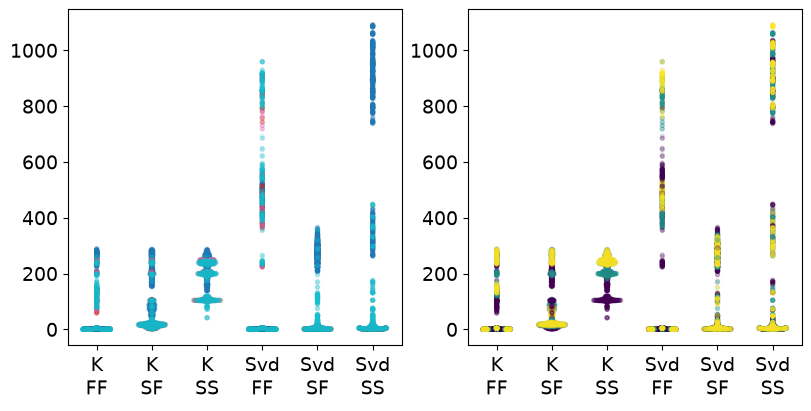

In [67]:
rms_kappa_ff_all = []
rms_kappa_sf_all = []
rms_kappa_ss_all = []
rms_svd_ff_all = []
rms_svd_sf_all = []
rms_svd_ss_all = []

# Set up color maps
colors_simulations = plt.colormaps["tab10"](np.linspace(0, 1, len(aggregators)))
color_map_simulations = dict(zip(aggregators.keys(), colors_simulations))
num_neurons_all = np.unique(np.concatenate([np.array(agg.param_axes["num_neurons"]) for agg in aggregators.values()]))
colors_neurons = plt.colormaps["viridis"](np.linspace(0, 1, len(num_neurons_all)))
color_map_neurons = dict(zip(num_neurons_all, colors_neurons))

colors_simulation = []
colors_neurons = []

for icolor, (name, agg) in enumerate(aggregators.items()):
    arrays, param_sizes = sel_kappa(agg)
    add_log_rms_error_fields(arrays, candidate_key="empirical_kappa_ff", reference_key="oracle_kappa_ff", out_key="rms_kappa_ff")
    add_log_rms_error_fields(arrays, candidate_key="empirical_kappa_sf", reference_key="oracle_kappa_sf", out_key="rms_kappa_sf")
    add_log_rms_error_fields(arrays, candidate_key="empirical_kappa_ss", reference_key="oracle_kappa_ss", out_key="rms_kappa_ss")
    add_log_rms_error_fields(arrays, candidate_key="empirical_svd_ff", reference_key="oracle_svd_ff", out_key="rms_svd_ff")
    add_log_rms_error_fields(arrays, candidate_key="empirical_svd_sf", reference_key="oracle_svd_sf", out_key="rms_svd_sf", permit_shortening=True)
    add_log_rms_error_fields(arrays, candidate_key="empirical_svd_ss", reference_key="oracle_svd_ss", out_key="rms_svd_ss", permit_shortening=True)

    rms_kappa_ff = arrays["rms_kappa_ff"].ravel()
    rms_kappa_sf = arrays["rms_kappa_sf"].ravel()
    rms_kappa_ss = arrays["rms_kappa_ss"].ravel()
    rms_svd_ff = arrays["rms_svd_ff"].ravel()
    rms_svd_sf = arrays["rms_svd_sf"].ravel()
    rms_svd_ss = arrays["rms_svd_ss"].ravel()
    valid = (
        np.isfinite(rms_kappa_ff)
        & np.isfinite(rms_kappa_sf)
        & np.isfinite(rms_kappa_ss)
        & np.isfinite(rms_svd_ff)
        & np.isfinite(rms_svd_sf)
        & np.isfinite(rms_svd_ss)
    )

    rms_kappa_ff_all.append(rms_kappa_ff[valid])
    rms_kappa_sf_all.append(rms_kappa_sf[valid])
    rms_kappa_ss_all.append(rms_kappa_ss[valid])
    rms_svd_ff_all.append(rms_svd_ff[valid])
    rms_svd_sf_all.append(rms_svd_sf[valid])
    rms_svd_ss_all.append(rms_svd_ss[valid])
    colors_simulation.extend([name] * valid.sum())

    num_neurons_idx = list(param_sizes).index("num_neurons")
    num_neurons = np.array(agg.param_axes["num_neurons"])
    target_shape = arrays["rms_kappa_ff"].shape
    view = [1] * len(target_shape)
    view[num_neurons_idx] = -1
    num_neurons_array = np.broadcast_to(num_neurons.reshape(view), target_shape)
    num_neurons_array = num_neurons_array.ravel()
    colors_neurons.extend((num_neurons_array[valid]))

rms_kappa_ff_all = np.concatenate(rms_kappa_ff_all)
rms_kappa_sf_all = np.concatenate(rms_kappa_sf_all)
rms_kappa_ss_all = np.concatenate(rms_kappa_ss_all)
rms_svd_ff_all = np.concatenate(rms_svd_ff_all)
rms_svd_sf_all = np.concatenate(rms_svd_sf_all)
rms_svd_ss_all = np.concatenate(rms_svd_ss_all)
data = [
    rms_kappa_ff_all,
    rms_kappa_sf_all,
    rms_kappa_ss_all,
    rms_svd_ff_all,
    rms_svd_sf_all,
    rms_svd_ss_all,
]
xticks = range(len(data))
labels = ["K\nFF", "K\nSF", "K\nSS", "Svd\nFF", "Svd\nSF", "Svd\nSS"]
colors_simulation = np.stack([color_map_simulations[name] for name in colors_simulation])
colors_neurons = np.stack([color_map_neurons[n] for n in colors_neurons])

lim_extra = 0.1
beewidth = 0.25
fig, ax = plt.subplots(1, 2, figsize=(8, 4), layout="constrained")
for idx, d in enumerate(data):
    ax[0].scatter(xticks[idx] + beewidth * beeswarm(d, nbins=300), d, c=colors_simulation, s=8, alpha=0.1)
    ax[1].scatter(xticks[idx] + beewidth * beeswarm(d, nbins=300), d, c=colors_neurons, s=8, alpha=0.1)
ax[0].set_xticks(xticks, labels=labels)
ax[1].set_xticks(xticks, labels=labels)
plt.show()

## Single simulation: candidate vs reference log-RMS error

Pick one grid cell (same `PL_*`-style sweep / partial param filter / seed) and
inspect a single `add_log_rms_error_fields` comparison: overlay candidate and
reference spectra, with per-dimension squared log error below.

In [68]:
LOG_RMS_COMPARISONS = {
    "rms_kappa_ff": ("empirical_kappa_ff", "oracle_kappa_ff", False),
    "rms_kappa_sf": ("empirical_kappa_sf", "oracle_kappa_sf", False),
    "rms_kappa_ss": ("empirical_kappa_ss", "oracle_kappa_ss", False),
    "rms_svd_ff": ("empirical_svd_ff", "oracle_svd_ff", False),
    "rms_svd_sf": ("empirical_svd_sf", "oracle_svd_sf", True),
    "rms_svd_ss": ("empirical_svd_ss", "oracle_svd_ss", True),
}


def _trim_trailing_nans(spec: np.ndarray) -> np.ndarray:
    """Return spectrum with trailing NaNs removed."""
    spec = np.asarray(spec, dtype=float)
    last = np.where(np.isfinite(spec))[0]
    if len(last) == 0:
        return spec
    return spec[: last[-1] + 1]


def pick_spectrum_pair(
    sweep: str,
    comp_key: str,
    sel: dict,
    seed: int | None = 0,
    min_points: int = 10,
) -> tuple[np.ndarray, np.ndarray, dict, np.ndarray, float]:
    """Draw one grid point's candidate/reference pair for a log-RMS comparison.

    ``comp_key`` is one of ``LOG_RMS_COMPARISONS`` (e.g. ``"rms_kappa_ff"``).
    Returns ``(candidate, reference, combo, sq_log_err, mean_sq_log_err)``.
    """
    if comp_key not in LOG_RMS_COMPARISONS:
        raise ValueError(
            f"Unknown comparison {comp_key!r}; choose from {sorted(LOG_RMS_COMPARISONS)}"
        )

    candidate_key, reference_key, permit_shortening = LOG_RMS_COMPARISONS[comp_key]
    agg = aggregators[sweep]
    arrays, sizes = agg.sel(
        keys=[candidate_key, reference_key],
        return_param_sizes=True,
        **sel,
    )
    cand = np.asarray(arrays[candidate_key], dtype=float)
    ref = np.asarray(arrays[reference_key], dtype=float)

    if cand.shape[-1] != ref.shape[-1]:
        if permit_shortening:
            shorter = min(cand.shape[-1], ref.shape[-1])
            cand = cand[..., :shorter]
            ref = ref[..., :shorter]
        else:
            raise ValueError(
                f"Candidate {candidate_key!r} and reference {reference_key!r} "
                "must have the same trailing dimension"
            )

    axis_shape = cand.shape[:-1]
    cand_flat = cand.reshape(-1, cand.shape[-1])
    ref_flat = ref.reshape(-1, ref.shape[-1])

    good = [
        i
        for i in range(cand_flat.shape[0])
        if (
            (np.isfinite(cand_flat[i]) & (cand_flat[i] > 0)).sum() >= min_points
            and (np.isfinite(ref_flat[i]) & (ref_flat[i] > 0)).sum() >= min_points
        )
    ]
    if not good:
        raise ValueError(f"No usable pairs for {sweep!r}/{comp_key!r} with {sel}")

    rng = np.random.default_rng(seed)
    i = int(rng.choice(good))
    candidate = _trim_trailing_nans(cand_flat[i])
    reference = _trim_trailing_nans(ref_flat[i])

    n = min(len(candidate), len(reference))
    candidate = candidate[:n]
    reference = reference[:n]

    valid = np.isfinite(candidate) & np.isfinite(reference) & (candidate > 0) & (reference > 0)
    sq_log_err = np.full(n, np.nan)
    with np.errstate(invalid="ignore", divide="ignore"):
        sq_log_err[valid] = (np.log(candidate[valid]) - np.log(reference[valid])) ** 2
    mean_sq_log_err = float(np.nanmean(sq_log_err))

    combo = {}
    if axis_shape:
        idx = np.unravel_index(i, axis_shape)
        for axis, j in zip(sizes.keys(), idx):
            combo[axis] = agg.param_axes[axis][j]

    return candidate, reference, combo, sq_log_err, mean_sq_log_err

placefield_tilbury | rms_svd_sf | drawn cell: {'repeat_noise_alpha': 0.0, 'noise_level': 0.0, 'nuisance_scale': 3.0, 'sigma_mean': 8.0, 'exponent_mean': 2.5, 'exponent_spread': 0.0}
  candidate: empirical_svd_sf
  reference: oracle_svd_sf
  mean squared log error: 1.866361
  mean weighted squared log error: 0.000010


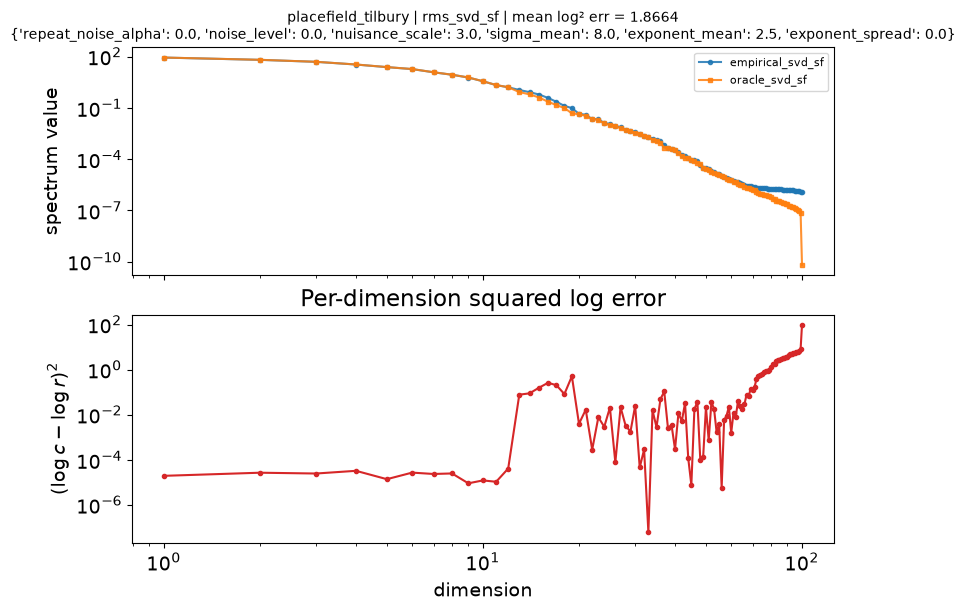

In [115]:
# === Tunables — edit these and re-run the plot cell below ===
COMP_SWEEP = "placefield_tilbury"   # stim_full / placefield_thresholded / placefield_smooth / placefield_tilbury
COMP_SEL = dict(num_neurons=500)    # partial param filter; unspecified axes are chosen at random
COMP_KEY = "rms_svd_sf"           # one of LOG_RMS_COMPARISONS (the 6 add_log_rms_error comparisons)
COMP_SEED = None                    # random draw; set an int to fix the grid cell

candidate, reference, combo, sq_log_err, mean_rms = pick_spectrum_pair(
    COMP_SWEEP, COMP_KEY, COMP_SEL, seed=COMP_SEED,
)
candidate_key, reference_key, _ = LOG_RMS_COMPARISONS[COMP_KEY]
print(f"{COMP_SWEEP} | {COMP_KEY} | drawn cell: {combo}")
print(f"  candidate: {candidate_key}")
print(f"  reference: {reference_key}")
print(f"  mean squared log error: {mean_rms:.6f}")

dims = np.arange(1, len(sq_log_err) + 1)

# Measure weighted error
err_valid = np.isfinite(sq_log_err)
err_total = np.sum(sq_log_err[err_valid])
err_weights = reference[err_valid] / np.sum(reference[err_valid])
err_weighted = sq_log_err[err_valid] * err_weights
print(f"  mean weighted squared log error: {np.nanmean(err_weighted):.6f}")


fig, (ax_spec, ax_err) = plt.subplots(2, 1, figsize=(8, 6), layout="constrained", sharex=True)

pos_c = np.isfinite(candidate) & (candidate > 0)
pos_r = np.isfinite(reference) & (reference > 0)
ax_spec.loglog(dims[pos_c], candidate[pos_c], "o-", ms=3, label=candidate_key, alpha=0.85)
ax_spec.loglog(dims[pos_r], reference[pos_r], "s-", ms=3, label=reference_key, alpha=0.85)
ax_spec.set_ylabel("spectrum value")
ax_spec.set_title(
    f"{COMP_SWEEP} | {COMP_KEY} | mean log² err = {mean_rms:.4f}\n{combo}",
    fontsize=10,
)
ax_spec.legend(fontsize=8)

ax_err.semilogy(dims[err_valid], sq_log_err[err_valid], "o-", ms=3, color="tab:red")
ax_err.set_xlabel("dimension")
ax_err.set_ylabel(r"$(\log c - \log r)^2$")
ax_err.set_title("Per-dimension squared log error")
plt.show()

## Power-law exponent (alpha) from spectra

Robust `alpha` estimation via `dimilibi.fit_powerlaw_spectrum`: it finds the region boundary
`search_end` from three bad-tail signals (smoothed noise-floor crossing, trailing positive fraction,
and a **cliff** = a big drop-off seen as a local-exponent spike), fits `lambda_k = A*(k+1)^(-alpha)`
over a grid of sub-windows inside it, and reports the exponent of the **longest window whose fit is
consistent** (`R^2 >= r2_min`) - which includes the head when it stays straight and excludes floors /
cliffs.

Edit the tunables cell, then run the single-fit and grid cells. `PL_KEY` accepts any key printed by
the tunables cell (empirical/oracle SVD & kappa spectra, oracle lambda spectra).

In [7]:
from dimilibi import fit_powerlaw_spectrum, plot_powerlaw_fit, fit_powerlaw_decay

# Keys whose stored value is a 1-D spectrum we can power-law fit.
ALL_SPECTRUM_KEYS = sorted(
    set(SVD_KEYS)
    | set(KAPPA_KEYS)
    | {"oracle_lambda_stim", "oracle_lambda_stim_nuisance", "oracle_lambda_full"}
)


def pick_spectrum(sweep, key, sel, seed=0, min_points=10):
    """Draw one grid point's spectrum from a sweep aggregator.

    Filters to usable spectra (enough finite/positive points), random-picks one of the
    remaining grid cells, and returns ``(spectrum, param_combo)`` where ``param_combo``
    names the parameter values of the drawn cell.
    """
    agg = aggregators[sweep]
    arrays, sizes = agg.sel(keys=[key], return_param_sizes=True, **sel)
    arr = np.asarray(arrays[key], dtype=float)
    axis_shape = arr.shape[:-1]
    flat = arr.reshape(-1, arr.shape[-1])

    good = [
        i for i in range(flat.shape[0])
        if np.isfinite(flat[i]).sum() > min_points and (flat[i] > 0).sum() >= min_points
    ]
    if not good:
        raise ValueError(f"No usable spectra for {sweep!r}/{key!r} with {sel}")

    rng = np.random.default_rng(seed)
    i = int(rng.choice(good))
    spec = flat[i]

    # Remove trailing NaNs
    _nan_spec = np.isnan(spec)
    _last_not_nan = np.where(~_nan_spec)[0]
    if len(_last_not_nan) == 0:
        _last_not_nan = len(spec)
    else:
        _last_not_nan = _last_not_nan[-1] + 1

    spec_valid = spec[:_last_not_nan]
    combo = {}
    if axis_shape:
        idx = np.unravel_index(i, axis_shape)
        for axis, j in zip(sizes.keys(), idx):
            combo[axis] = agg.param_axes[axis][j]

    return spec_valid, combo

In [8]:
print("available spectrum keys:")
print("  " + "\n  ".join(ALL_SPECTRUM_KEYS))

available spectrum keys:
  empirical_kappa_ff
  empirical_kappa_sf
  empirical_kappa_ss
  empirical_svd_ff
  empirical_svd_sf
  empirical_svd_sf_cv
  empirical_svd_ss
  empirical_svd_ss_cv
  oracle_kappa_ff
  oracle_kappa_sf
  oracle_kappa_ss
  oracle_lambda_full
  oracle_lambda_stim
  oracle_lambda_stim_nuisance
  oracle_svd_ff
  oracle_svd_sf
  oracle_svd_ss


In [ ]:
# === Tunables — edit these and re-run the two cells below ===
PL_SWEEP = "placefield_tilbury"            # which aggregator: stim_full / placefield_thresholded / placefield_smooth / placefield_tilbury
PL_KEY = "oracle_kappa_ss"    # any key in ALL_SPECTRUM_KEYS (svd / kappa / oracle lambda)
PL_SEL = dict(num_neurons=500)    # partial param filter; unspecified axes are chosen at random
PL_KW = dict(                     # fit_powerlaw_spectrum kwargs
    smooth_width=5,               # boxcar points averaged for region detection
    deriv_width=1,
    tail_positive_frac=0.9,
    min_head=2,
    min_window=5,
)
PL_SEED = None                     # random draw for the single-fit cell
PL_N_EXAMPLES = 6                 # rows in the grid cell
PL_GRID_SEED = 100                # base seed for the grid cell (each row uses PL_GRID_SEED + r)

# Single fit + 3-panel diagnostic for the config above.
spectrum, combo = pick_spectrum(PL_SWEEP, PL_KEY, PL_SEL, seed=PL_SEED)
print("drawn cell:", combo)
fit = fit_powerlaw_spectrum(spectrum, **PL_KW)
print(f"alpha = {fit.alpha:.3f} +/- {fit.alpha_std:.3f}  (16-84%: {fit.alpha_lo:.3f} .. {fit.alpha_hi:.3f})")
print(f"region [head_end, tail_end) = [{fit.head_end}, {fit.tail_end}), "
      f"n_valid={fit.n_valid}, ensemble_size={fit.ensemble_alphas.size}")
fit.plot()
plt.show()

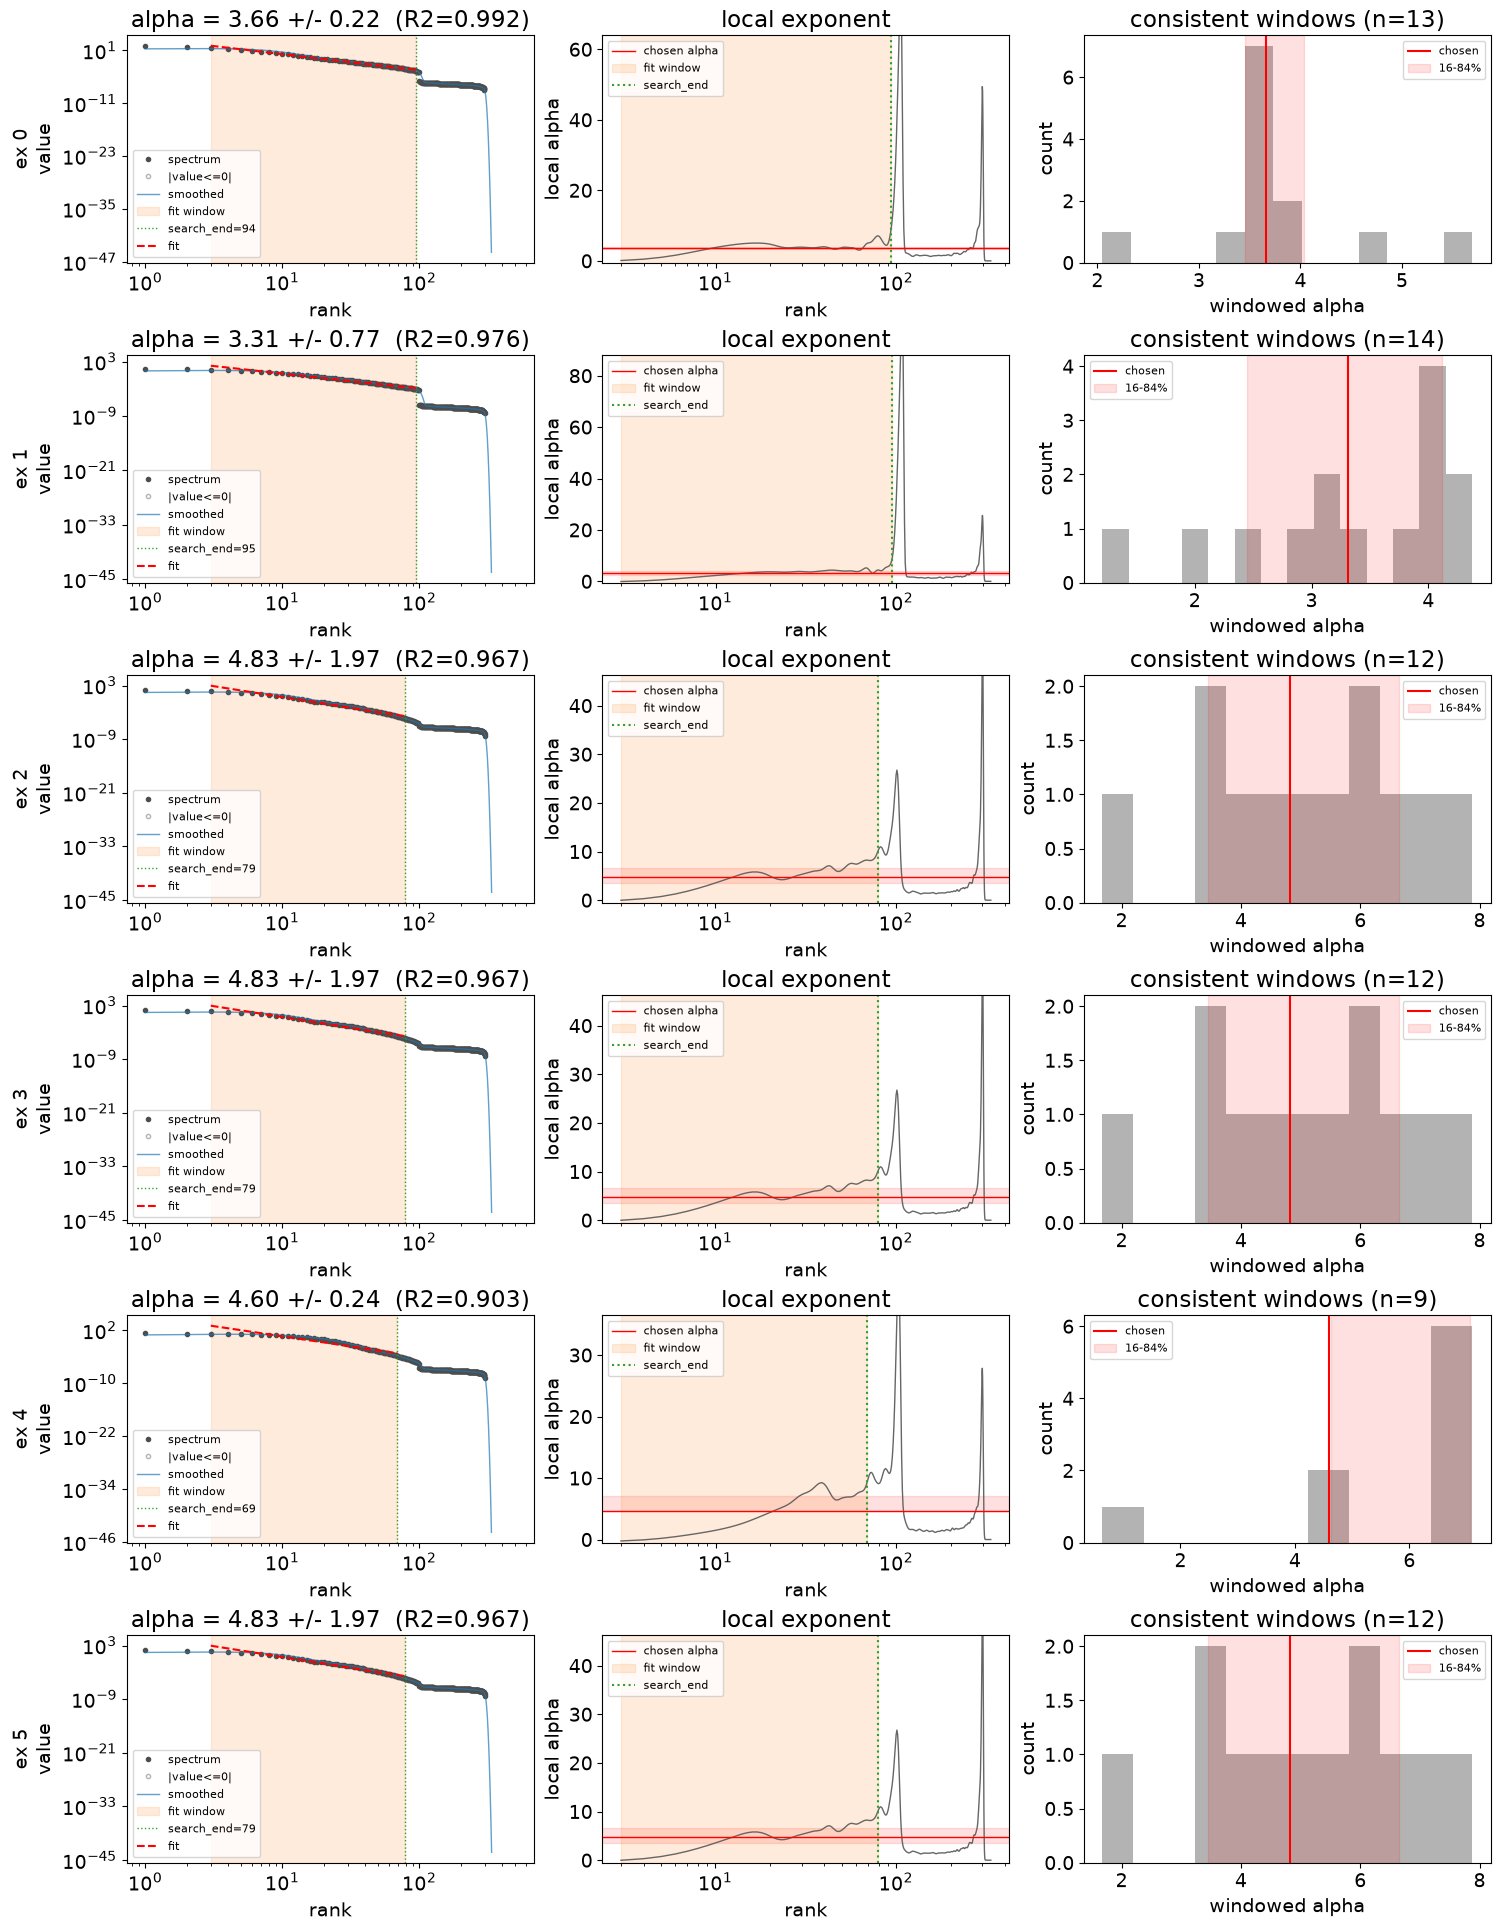

In [10]:
# Grid of random examples: fit many spectra at once to eyeball robustness.
# Change PL_N_EXAMPLES / PL_GRID_SEED (or PL_SWEEP / PL_KEY above) and re-run.
fig, axs = plt.subplots(PL_N_EXAMPLES, 3, figsize=(15, 3.2 * PL_N_EXAMPLES), layout="constrained")
axs = np.atleast_2d(axs)
for r in range(PL_N_EXAMPLES):
    spec_r, combo_r = pick_spectrum(PL_SWEEP, PL_KEY, PL_SEL, seed=PL_GRID_SEED + r)
    fit_r = fit_powerlaw_spectrum(spec_r, **PL_KW)
    plot_powerlaw_fit(fit_r, axes=axs[r])
    axs[r, 0].set_ylabel(f"ex {r}\nvalue")
plt.show()

## Opening up `fit_powerlaw_spectrum`, step by step

The cells below recompute each internal stage of `fit_powerlaw_spectrum` on a single spectrum and
plot the choices it makes, so you can validate/tune the workflow. They read the same `PL_*` config
from the tunables cell above - change `PL_KEY` / `PL_SEL` / `PL_SEED` / the params dict, re-run this
whole section, and watch every step update.

Pipeline: **(1) smooth -> (2) local exponent -> (3) region end (incl. cliff) -> (4) fit a grid of
windows and pick the longest consistent one -> (5) report alpha + spread.**

> Tip: try `PL_KEY="oracle_svd_sf"` (power-law head then a numerical-floor cliff - watch `cliff`
> stop `search_end` at the drop-off) vs `PL_KEY="empirical_svd_sf_cv"` (noisy CV tail).

In [43]:
# === Tunables — edit these and re-run the two cells below ===
PL_SWEEP = "stim_full"            # which aggregator: stim_full / placefield_thresholded / placefield_smooth / placefield_tilbury
PL_KEY = "empirical_svd_ss_cv"    # any key in ALL_SPECTRUM_KEYS (svd / kappa / oracle lambda)
PL_SEL = dict(num_neurons=500)    # partial param filter; unspecified axes are chosen at random
PL_SEED = None                       # random draw for the single-fit cell
PL_N_EXAMPLES = 6                 # rows in the grid cell
PL_GRID_SEED = None             # base seed for the grid cell (each row uses PL_GRID_SEED + r)

spec, combo = pick_spectrum(PL_SWEEP, PL_KEY, PL_SEL, seed=PL_SEED)
spec = np.asarray(spec, dtype=float)
N = spec.size
valid_mask = np.isfinite(spec) & (spec > 0)

PL_KW = dict(
    smooth_width=5,               # boxcar points averaged for region detection
    deriv_width=1,
    min_head=2,
    min_window=5,
    tail_positive_frac=0.9,
    cliff_alpha=10.0,
    r2_min=0.9,
    n_windows=24,
    percentiles=(15.0, 85.0),
    eps=1e-8,
)
smooth_width = PL_KW["smooth_width"]
deriv_width = PL_KW["deriv_width"]
min_head = int(np.clip(PL_KW["min_head"], 0, N - 1))
min_window = PL_KW["min_window"]
tail_positive_frac = PL_KW["tail_positive_frac"]
cliff_alpha = PL_KW["cliff_alpha"]
r2_min = PL_KW["r2_min"]
n_windows = PL_KW["n_windows"]
percentiles = PL_KW["percentiles"]

print(f"{PL_SWEEP} | drawn cell: {combo}")
print(f"N={N}  valid (finite & >0)={int(valid_mask.sum())}  params={PL_KW}")

stim_full | drawn cell: {'stim_dim': 20, 'alpha_stim': 3.0, 'nuisance_dim': 20, 'nuisance_scale': 0.1, 'nuisance_alignment': 'random', 'noise_scale': 0.1}
N=100  valid (finite & >0)=65  params={'smooth_width': 5, 'deriv_width': 1, 'min_head': 2, 'min_window': 5, 'tail_positive_frac': 0.9, 'cliff_alpha': 10.0, 'r2_min': 0.9, 'n_windows': 24, 'percentiles': (15.0, 85.0), 'eps': 1e-08}


### Step 1 - smoothing (detection only)

A **smoothed copy** is used *only* to detect regions; the raw spectrum is what gets fit. It is a
**boxcar moving average of `smooth_width` points**, applied over the finite entries only (NaNs, e.g.
ragged-aggregate padding, are skipped rather than propagated; NaN positions stay NaN).

- `smooth_width` - number of points averaged (`None` = use raw). Boxcar width is intuitive: `5` means
  a 5-point moving average, unlike a gaussian kernel width which smooths much wider than it reads.

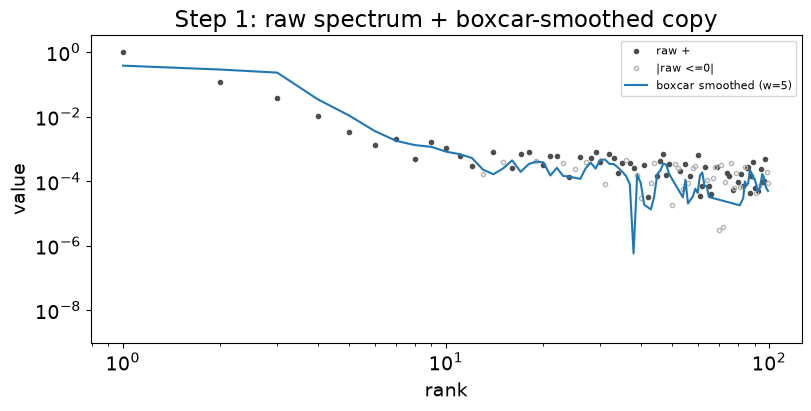

In [44]:
# Step 1: smoothed copy for region detection - boxcar moving average of `smooth_width`
# points over the finite entries (NaNs skipped, not propagated; edge-normalized).
finite_idx = np.flatnonzero(np.isfinite(spec))
w = max(1, int(round(smooth_width)))
smoothed = np.full(N, np.nan)
if finite_idx.size:
    v = spec[finite_idx]
    if w == 1:
        smoothed[finite_idx] = v
    else:
        ones = np.ones(w)
        counts = np.convolve(np.ones(v.size), ones, mode="same")
        smoothed[finite_idx] = np.convolve(v, ones, mode="same") / counts
ranks = np.arange(N) + 1

fig, ax = plt.subplots(figsize=(8, 4), layout="constrained")
ax.loglog(ranks[valid_mask], spec[valid_mask], "o", ms=3, color="0.3", label="raw +")
neg = np.isfinite(spec) & (spec <= 0)
if neg.any():
    ax.loglog(ranks[neg], np.abs(spec[neg]), "o", ms=3, mfc="none", mec="0.7", label="|raw <=0|")
sp = smoothed > 0
ax.loglog(ranks[sp], smoothed[sp], "-", color="tab:blue", label=f"boxcar smoothed (w={w})")
ax.set_xlabel("rank"); ax.set_ylabel("value")
ax.set_title("Step 1: raw spectrum + boxcar-smoothed copy")
ax.set_ylim((1e-9, None))
ax.legend(fontsize=8)
plt.show()

### Step 2 - local exponent (power-law / cliff detector)

`fit_powerlaw_derivatives` gives a per-rank slope `alpha(k) = -k * d(log lambda)/dk`. A pure power law
is a straight log-log line, so this is **flat** at the true exponent. A **cliff** (a big drop-off into
a numerical floor, or the edge of the signal) shows up as a sharp **spike** far above the power-law
level - that spike is what marks the bad tail in Step 3. On the floor after the cliff it reads back
near zero. NaN wherever the smoothed value is <= 0.

- `deriv_width` - stencil half-width (bigger = smoother, needs `N >= 4*deriv_width + 1`).
- `cliff_alpha` - the spike threshold used next to call something a cliff.

finite local_alpha: 496 / 500   max=548.3 (cliff_alpha=10.0)


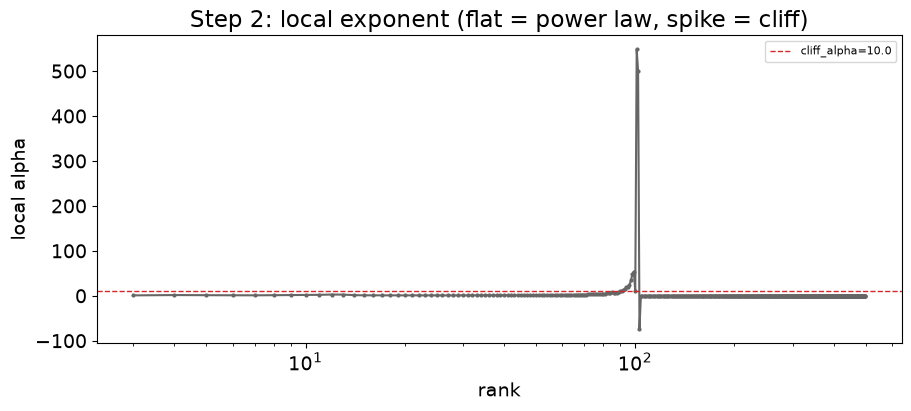

In [30]:
# Step 2: per-rank local exponent alpha(k) = -k * d(log lambda)/dk (five-point stencil).
local_alpha = np.full(N, np.nan)
if N >= 4 * deriv_width + 1:
    la, sl = fit_powerlaw_derivatives(smoothed, width=deriv_width, axis=0, eps=1e-8)
    local_alpha[sl] = np.asarray(la, dtype=float)
print(f"finite local_alpha: {int(np.isfinite(local_alpha).sum())} / {N}   "
      f"max={np.nanmax(local_alpha):.1f} (cliff_alpha={cliff_alpha})")

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
ax.plot(ranks, local_alpha, "-o", ms=2, color="0.4")
ax.axhline(cliff_alpha, color="tab:red", ls="--", lw=1, label=f"cliff_alpha={cliff_alpha}")
ax.set_xscale("log")
ax.set_xlabel("rank")
ax.set_ylabel("local alpha")
ax.set_title("Step 2: local exponent (flat = power law, spike = cliff)")
ax.legend(fontsize=8)
plt.show()

### Step 3 - region end (`search_end`)

The fit is only searched over `[min_head, search_end)`. `search_end` is the **earliest** of three
bad-tail signals:

- **smoothed <= 0** - the smoothed curve crosses the noise floor.
- **trailing positive fraction < `tail_positive_frac`** - positives thin out (noisy CV tails).
- **cliff** - the local exponent spikes above `cliff_alpha` (a big drop-off / numerical floor).

The cliff criterion is the one that fixes the "fit sitting on a flat numerical floor" case: the drop
into the floor spikes the local exponent, so `search_end` lands right at the cliff and the floor is
excluded.

smoothed_cross=500  frac_cross=496  cliff_cross=89  ->  search_end=89


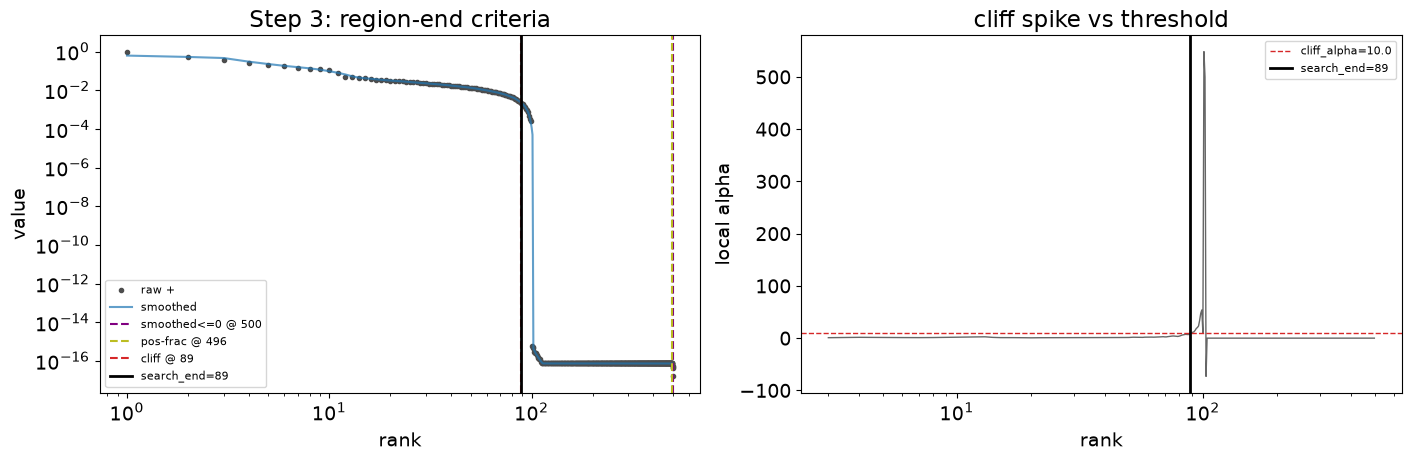

In [31]:
# Step 3: region end = earliest of smoothed<=0, positive-fraction drop, and cliff spike.
nonpos = ~(smoothed > 0)
nonpos[:min_head] = False
smoothed_cross = int(np.argmax(nonpos)) if nonpos.any() else N

frac_window = max(min_window, int(round(2 * (smooth_width or 1))) + 1)
trailing_frac = np.convolve(valid_mask.astype(float), np.ones(frac_window) / frac_window, mode="same")
below = trailing_frac < tail_positive_frac
below[:max(min_head, frac_window)] = False
frac_cross = int(np.argmax(below)) if below.any() else N

cliff = np.isfinite(local_alpha) & (local_alpha > cliff_alpha)
cliff[:min_head] = False
cliff_cross = int(np.argmax(cliff)) if cliff.any() else N

search_end = int(min(smoothed_cross, frac_cross, cliff_cross, N))
search_end = min(max(search_end, min_head + min_window), N)
print(f"smoothed_cross={smoothed_cross}  frac_cross={frac_cross}  cliff_cross={cliff_cross}  ->  search_end={search_end}")

fig, (a0, a1) = plt.subplots(1, 2, figsize=(14, 4.5), layout="constrained")
a0.loglog(ranks[valid_mask], spec[valid_mask], "o", ms=3, color="0.3", label="raw +")
sp = smoothed > 0
a0.loglog(ranks[sp], smoothed[sp], "-", color="tab:blue", alpha=0.7, label="smoothed")
a0.axvline(smoothed_cross, color="purple", ls="--", label=f"smoothed<=0 @ {smoothed_cross}")
a0.axvline(frac_cross, color="tab:olive", ls="--", label=f"pos-frac @ {frac_cross}")
a0.axvline(cliff_cross, color="tab:red", ls="--", label=f"cliff @ {cliff_cross}")
a0.axvline(search_end, color="k", lw=2, label=f"search_end={search_end}")
a0.set_xlabel("rank"); a0.set_ylabel("value"); a0.set_title("Step 3: region-end criteria")
a0.legend(fontsize=8)

a1.plot(ranks, local_alpha, "-", color="0.4", lw=1)
a1.axhline(cliff_alpha, color="tab:red", ls="--", lw=1, label=f"cliff_alpha={cliff_alpha}")
a1.axvline(search_end, color="k", lw=2, label=f"search_end={search_end}")
a1.set_xscale("log"); a1.set_xlabel("rank"); a1.set_ylabel("local alpha")
a1.set_title("cliff spike vs threshold")
a1.legend(fontsize=8)
plt.show()

### Step 4 - window grid, and pick the longest consistent one

Sweep a grid of `start` x `end` windows inside `[min_head, search_end)`, fit each as a log-log line,
and score it by R^2. The chosen fit is the **longest window with `R^2 >= r2_min`** (ties broken by
reaching the deepest rank, then starting earliest). Maximising the fitted rank range this way
**includes the head when it stays straight** and drops it when it curves (a head-including window
would fail `r2_min`). Below, each window is a segment colored by R^2; the chosen one is highlighted.

- `r2_min` - consistency bar. Raise it to demand straighter fits (favours the cleanest stretch);
  lower it to allow longer, looser fits.
- `min_window`, `n_windows` - minimum window length and grid density.

14 windows fit, 14 consistent (R2>=0.9); chosen=[2, 89)  alpha=1.337  R2=0.952


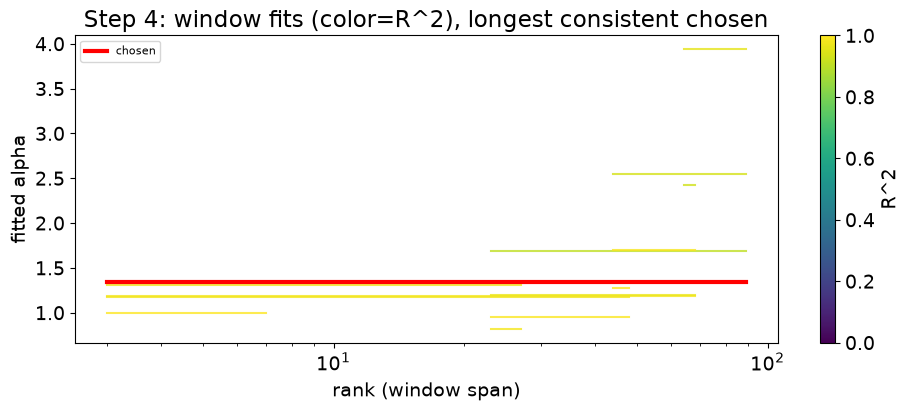

In [32]:
# Step 4: fit every grid window, score by R^2, choose the longest consistent one.
n_side = max(2, int(np.ceil(np.sqrt(n_windows))))
starts = np.unique(np.linspace(min_head, max(min_head, search_end - min_window), n_side).astype(int))
ends = np.unique(np.linspace(min(min_head + min_window, search_end), search_end, n_side).astype(int))

rows = []  # (start, end, alpha, r2)
for s in starts:
    for e in ends:
        if e - s < min_window or int(valid_mask[s:e].sum()) < min_window:
            continue
        try:
            a_w, amp_w = fit_powerlaw_decay(spec, int(s), int(e), ignore_nans=True, verbose=False)
        except (RuntimeError, ValueError, TypeError):
            continue
        if not np.isfinite(a_w):
            continue
        # log-log R^2
        rk = np.arange(s, e) + 1
        vv = spec[s:e]
        keep = np.isfinite(vv) & (vv > 0)
        if keep.sum() < 2 or not (np.isfinite(amp_w) and amp_w > 0):
            continue
        x, y = np.log(rk[keep]), np.log(vv[keep])
        pred = np.log(amp_w) - a_w * x
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1.0 - np.sum((y - pred) ** 2) / ss_tot if ss_tot > 0 else np.nan
        rows.append((int(s), int(e), float(a_w), float(r2)))

W = np.array([(s, e) for s, e, _, _ in rows]) if rows else np.empty((0, 2), int)
A = np.array([a for _, _, a, _ in rows]) if rows else np.empty(0)
R2 = np.array([r for _, _, _, r in rows]) if rows else np.empty(0)

# choose: longest span among R^2 >= r2_min (fallback: best R^2)
consistent = R2 >= r2_min
pool = np.flatnonzero(consistent) if consistent.any() else np.flatnonzero(np.isfinite(R2))
spans = W[:, 1] - W[:, 0]
best = pool[np.lexsort((W[pool, 0], -W[pool, 1], -spans[pool]))[0]]
print(f"{len(rows)} windows fit, {int(consistent.sum())} consistent (R2>={r2_min}); "
      f"chosen=[{W[best, 0]}, {W[best, 1]})  alpha={A[best]:.3f}  R2={R2[best]:.3f}")

fig, ax = plt.subplots(figsize=(9, 4), layout="constrained")
norm = plt.Normalize(0.0, 1.0)
cmap = plt.colormaps["viridis"]
for i, (s, e) in enumerate(W):
    ax.plot([s + 1, e], [A[i], A[i]], "-", color=cmap(norm(R2[i])), lw=1.5, alpha=0.8)
ax.plot([W[best, 0] + 1, W[best, 1]], [A[best], A[best]], "-", color="red", lw=3, label="chosen")
fig.colorbar(plt.cm.ScalarMappable(norm=norm, cmap=cmap), ax=ax, label="R^2")
ax.set_xscale("log")
ax.set_xlabel("rank (window span)")
ax.set_ylabel("fitted alpha")
ax.set_title("Step 4: window fits (color=R^2), longest consistent chosen")
ax.legend(fontsize=8)
plt.show()

### Step 5 - result and cross-check

The reported `alpha` is the chosen (longest consistent) window's exponent; `alpha_std` = `1.4826 * MAD`
and `alpha_lo/hi` = `percentiles` across the consistent windows (the spread). This cell rebuilds those
by hand and checks they match `fit_powerlaw_spectrum(spec, **PL_KW)` exactly.

manual  : alpha=1.3372 +/- 0.4779  (0.990..2.426)  window=[2, 89)  n_consistent=14
function: alpha=1.3372 +/- 0.4779  (0.990..2.426)  window=[2, 89)  n_consistent=14
match: True


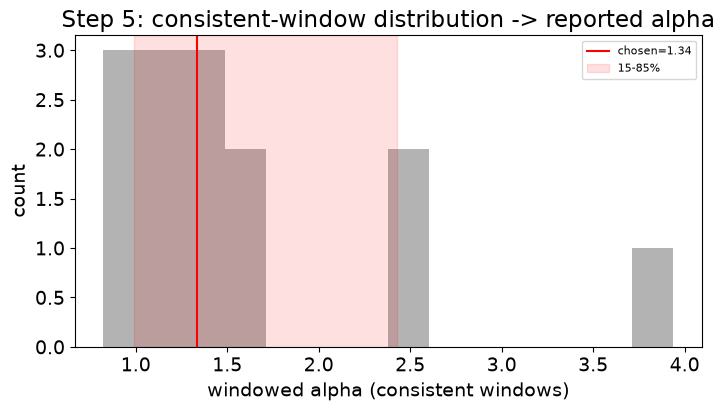

In [33]:
# Step 5: aggregate the consistent windows and cross-check against fit_powerlaw_spectrum().
ens = A[pool]
man_alpha = float(A[best])
man_std = 1.4826 * float(np.median(np.abs(ens - np.median(ens)))) if ens.size else 0.0
man_lo, man_hi = (np.percentile(ens, percentiles) if ens.size else (man_alpha, man_alpha))

ref = fit_powerlaw_spectrum(spec, **PL_KW)
print(f"manual  : alpha={man_alpha:.4f} +/- {man_std:.4f}  ({man_lo:.3f}..{man_hi:.3f})  "
      f"window=[{W[best, 0]}, {W[best, 1]})  n_consistent={ens.size}")
print(f"function: alpha={ref.alpha:.4f} +/- {ref.alpha_std:.4f}  ({ref.alpha_lo:.3f}..{ref.alpha_hi:.3f})  "
      f"window=[{ref.head_end}, {ref.tail_end})  n_consistent={ref.ensemble_alphas.size}")
print("match:", np.isclose(man_alpha, ref.alpha, equal_nan=True) and (W[best, 0] == ref.head_end) and (W[best, 1] == ref.tail_end))

fig, ax = plt.subplots(figsize=(7, 4), layout="constrained")
if ens.size:
    ax.hist(ens, bins=min(20, max(5, ens.size)), color="0.7")
    ax.axvline(man_alpha, color="r", lw=1.5, label=f"chosen={man_alpha:.2f}")
    ax.axvspan(man_lo, man_hi, color="r", alpha=0.12, label=f"{int(percentiles[0])}-{int(percentiles[1])}%")
    ax.legend(fontsize=8)
ax.set_xlabel("windowed alpha (consistent windows)")
ax.set_ylabel("count")
ax.set_title("Step 5: consistent-window distribution -> reported alpha")
plt.show()